# Training and Cross-Validation
---
Builds the MC-Dropout emulator and uses K-fold cross-validation to evaluate the architecture robustness then trains a single model for evaluation.

1. **K-fold cross-validation** - Measures how much the fit depends on which simulations land in the training split. Folds are scored with a single deterministic pass, dropout off, so the spread reflects the architecture rather than MC sampling noise. Generates figures:
    - Validation loss per fold
    - Minimum validation loss per fold
2. **Final training** - One model on the 70/10/20 split, restoring the best-validation checkpoint via early stopping. Generates figure:
    - MSE Loss Over Epoch & Mean Predictive STD Over Epoch

More information about the package can be found here: [Documentation](https://reionemu.org/)

In [1]:
import sys
import json

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset, TensorDataset
import matplotlib.pyplot as plt

from reionemu import (
    load_training_arrays,
    make_dataloaders,
    MCDropoutEmulator,
    fit,
    kfold_cross_validate,
    evaluate_metrics,
    evaluate_mc_metrics,
    mse,
    rmse,
    physical_mean_relative_error,
)

## Paths, Configs, and Constants

In [2]:
# Paths
from config import H5_PATH, CKPT_DIR, MODEL_PATH, NORM_PATH, FIG_DIR, EXPERIMENT_NAME, make_dirs
from config import HELDOUT_INDICES_PATH, TRAIN_RESULTS_PATH, KFOLD_SUMMARY_PATH

# Constants
from config import SEED, N_MC_EVAL, device

# Package configs
from config import SPLIT, dlcfg, kfcfg, kf_fitcfg, fitcfg

make_dirs()

## Seeding

In [3]:
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python:\t\t{sys.version.split()[0]}")
print("-" * 30)
print(f"NumPy:\t\t{np.__version__}")
print(f"PyTorch:\t{torch.__version__}")
print("-" * 30)
print(f"Global Seed:\t{SEED}")

Python:		3.13.1
------------------------------
NumPy:		2.5.2
PyTorch:	2.13.0
------------------------------
Global Seed:	42


## Build Dataloaders

In [4]:
loaders, norms, ell = make_dataloaders(
    h5_path=H5_PATH,
    split=SPLIT,
    config=dlcfg,
)

print(loaders)
print(norms)
print(ell)

{'train': <torch.utils.data.dataloader.DataLoader object at 0x11fc06cf0>, 'val': <torch.utils.data.dataloader.DataLoader object at 0x10cacda90>, 'test': <torch.utils.data.dataloader.DataLoader object at 0x11fc565d0>}
{'X': Normalizer(mean=array([7.9980483 , 0.49714097, 1.06111   , 0.45881906], dtype=float32), std=array([0.5698338, 0.2326668, 0.5521792, 0.2050817], dtype=float32)), 'Y': None}
[ 2033.4963  4093.4153  6153.3345  8213.253  10273.172 ]


## Prepare Model

In [5]:
modelcfg = {
    "input_dim": 4,
    "output_dim": 5,
    "hidden_dim": 20,
    "num_hidden_layers": 2,
    "activation": "relu",
    "dropout_rate": 0.1,
}
learning_rate = 1e-3
weight_decay = 1e-5

model = MCDropoutEmulator(**modelcfg)
lossfn = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

model

MCDropoutEmulator(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=20, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=20, out_features=20, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=20, out_features=5, bias=True)
  )
)

# K-Fold Cross-Validation
---
Fold losses below are scored with a single deterministic forward pass with **dropout off**. This isolates the architecture and optimizer from the stochasticity of MC dropout, so the fold-to-fold spread measures how robust the architecture is to the choice of training split.

In [6]:
%%time

def build_model():
    return MCDropoutEmulator(**modelcfg)

def build_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

def build_lossfn():
    return torch.nn.MSELoss()


kfold_results = kfold_cross_validate(
    h5_path=H5_PATH,
    model_builder=build_model,
    optimizer_builder=build_optimizer,
    loss_fn=build_lossfn(),
    kfold_config=kfcfg,
    dl_config=dlcfg,
    fit_config=kf_fitcfg,
)

print(kfold_results.keys())
print(f"Min Validation Loss Per Fold: {kfold_results['fold_best_val']}")
print(f"Mean Validation Loss (MSE): {kfold_results['mean_best_val']}")
print(f"STD Validation Loss: {kfold_results['std_best_val']}")


=== Fold 1/5 | train=800 val=200 ===
Epoch 001: train=0.296304, val=0.265049
Epoch 002: train=0.238211, val=0.209013
Epoch 003: train=0.182250, val=0.144832
Epoch 004: train=0.124684, val=0.081755
Epoch 005: train=0.078094, val=0.045045
Epoch 006: train=0.056903, val=0.032002
Epoch 007: train=0.050211, val=0.026206
Epoch 008: train=0.045585, val=0.021998
Epoch 009: train=0.041667, val=0.019807
Epoch 010: train=0.038759, val=0.017326
Epoch 011: train=0.036990, val=0.016150
Epoch 012: train=0.033968, val=0.015129
Epoch 013: train=0.032240, val=0.013622
Epoch 014: train=0.032470, val=0.013106
Epoch 015: train=0.029369, val=0.012749
Epoch 016: train=0.028137, val=0.012553
Epoch 017: train=0.030360, val=0.011879
Epoch 018: train=0.026676, val=0.011666
Epoch 019: train=0.023356, val=0.011606
Epoch 020: train=0.028653, val=0.010412
Epoch 021: train=0.024056, val=0.010395
Epoch 022: train=0.024034, val=0.010422
Epoch 023: train=0.023420, val=0.009943
Epoch 024: train=0.021332, val=0.009924
Ep

## K-Fold Cross-Validation: Validation Loss Per Fold

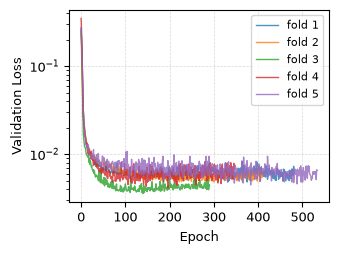

In [7]:
fig, ax = plt.subplots()

for i, h in enumerate(kfold_results["histories"]):
    ax.plot(h["val_loss"], label=f"fold {i + 1}", alpha=0.8, linewidth=1.0)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_yscale("log")

ax.legend(fontsize=8)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig(FIG_DIR / f'validation_loss_per_fold_{EXPERIMENT_NAME}.pdf', format='pdf', bbox_inches="tight")

plt.show()

## K-Fold Cross-Validation: Min Val Loss Per Fold

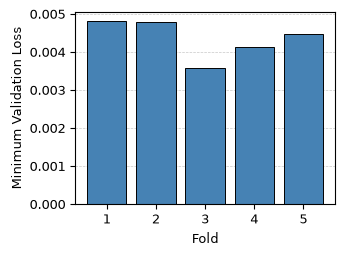

In [8]:
best_vals = np.array(kfold_results["fold_best_val"], dtype=float)
mean_val = kfold_results['mean_best_val']

fig, ax = plt.subplots()

ax.bar(np.arange(1, len(best_vals) + 1), best_vals, color='steelblue', alpha=1, edgecolor='black', linewidth=0.7)

ax.set_xlabel("Fold")
ax.set_ylabel("Minimum Validation Loss")

ax.set_xticks(np.arange(1, len(best_vals) + 1))

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

fig.savefig(FIG_DIR / f'best_validation_loss_per_fold_{EXPERIMENT_NAME}.pdf', format='pdf', bbox_inches="tight")
plt.show()

## K-Fold Cross-Validation: Metrics

In [9]:
print(f"Best Validation Loss Per Fold:\n\t{best_vals}")
print(f"Mean Validation Loss Across Folds:\n\t{mean_val:.4f}")
print(f"STD of Validation Loss Across Folds:\n\t{best_vals.std():.4f}")

Best Validation Loss Per Fold:
	[0.0048194  0.00479738 0.00357987 0.0041269  0.00447956]
Mean Validation Loss Across Folds:
	0.0044
STD of Validation Loss Across Folds:
	0.0005


# Supervised Training
---

## Reseed

In [10]:
np.random.seed(SEED)
torch.manual_seed(SEED)

## Train Model

In [11]:
%%time

model = MCDropoutEmulator(**modelcfg)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
lossfn = torch.nn.MSELoss()

train_results = fit(
    model,
    loaders["train"],
    loaders["val"],
    optimizer,
    lossfn,
    fitcfg,
    metrics={"Physical Mean Relative Error": physical_mean_relative_error, "RMSE": rmse, "MSE": mse},
    evaluation="evaluate_mc_metrics",
    n_mc_samples=N_MC_EVAL,
)

print(train_results)

Epoch 001: train=0.290863, val=0.289408, Physical Mean Relative Error=0.554304, RMSE=0.535189, MSE=0.289408, predictive_std=0.042955
Epoch 002: train=0.240782, val=0.242113, Physical Mean Relative Error=0.491370, RMSE=0.488904, MSE=0.242113, predictive_std=0.051841
Epoch 003: train=0.187837, val=0.189901, Physical Mean Relative Error=0.412413, RMSE=0.432151, MSE=0.189901, predictive_std=0.067860
Epoch 004: train=0.141395, val=0.131580, Physical Mean Relative Error=0.321496, RMSE=0.357954, MSE=0.131580, predictive_std=0.088447
Epoch 005: train=0.093161, val=0.079681, Physical Mean Relative Error=0.229232, RMSE=0.276833, MSE=0.079681, predictive_std=0.111149
Epoch 006: train=0.064155, val=0.053486, Physical Mean Relative Error=0.177458, RMSE=0.226012, MSE=0.053486, predictive_std=0.127054
Epoch 007: train=0.050267, val=0.041677, Physical Mean Relative Error=0.154798, RMSE=0.199586, MSE=0.041677, predictive_std=0.131914
Epoch 008: train=0.048815, val=0.036903, Physical Mean Relative Error

## Training: MSE Loss Over Epoch & Mean Predictive STD Over Epoch

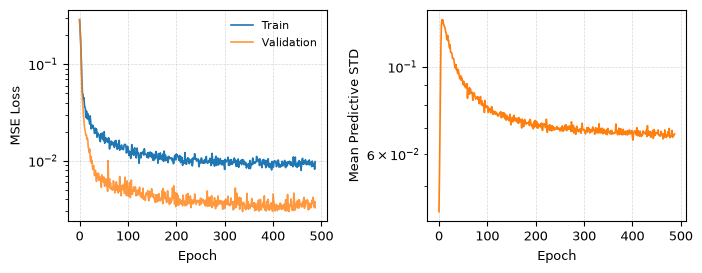

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(7.1, 2.8))

# Loss
ax[0].plot(train_results["train_loss"], label="Train", linewidth=1.2)
ax[0].plot(train_results["val_loss"], label="Validation", linewidth=1.2, alpha=0.8)

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE Loss")
ax[0].set_yscale("log")

# ax[0].set_title("(a)", loc="left", fontweight="bold")

ax[0].legend(frameon=False, fontsize=8)
ax[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)


# MC-Dropout Uncertainty
ax[1].plot(train_results["val_mean_predictive_std"], color="tab:orange", linewidth=1.2)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean Predictive STD")
ax[1].set_yscale("log")

# ax[1].set_title("(b)", loc="left", fontweight="bold")

ax[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.5)


plt.tight_layout()

fig.savefig(FIG_DIR / f'training_loss_and_mc_dropout_uncertainty_{EXPERIMENT_NAME}.pdf', format='pdf', bbox_inches="tight")
plt.show()


### Number of Epochs

In [13]:
best_epoch = int(np.argmin(train_results["val_loss"]))
print(f"Number of Epochs: {len(train_results['train_loss'])}")
print(f"Best Epoch (restored checkpoint): {best_epoch + 1}")
print(f"\ttrain = {train_results['train_loss'][best_epoch]:.5f}")
print(f"\tval = {train_results['val_loss'][best_epoch]:.5f}")
print(f"\tmean predictive std = {train_results['val_mean_predictive_std'][best_epoch]:.5f}")

Number of Epochs: 488
Best Epoch (restored checkpoint): 338
	train = 0.00958
	val = 0.00299
	mean predictive std = 0.06999


## Validation Loss: Like-for-Like Comparison

The k-fold section scores folds deterministically (dropout off); the training run scores the MC-dropout predictive mean (dropout on). Two things differ between those numbers, the evaluation protocol and which metric selected the checkpoint. This cell separates them by measuring both effects instead of asserting one.

In [14]:
final_val_deterministic = evaluate_metrics(model, loaders["val"], lossfn, device)["loss"]
final_val_mc = evaluate_mc_metrics(model, loaders["val"], lossfn, device, n_mc_samples=N_MC_EVAL)["loss"]

X_kf, Y_kf, _ = load_training_arrays(H5_PATH)

fold_det, fold_mc = [], []
for fold_model, fold_norm, fold_val_idx in zip(kfold_results["models"], kfold_results["norms"], kfold_results["val_indices"]):
    X_fold = (X_kf if fold_norm["X"] is None else (X_kf - fold_norm["X"].mean) / fold_norm["X"].std)
    fold_loader = DataLoader(
        Subset(TensorDataset(torch.from_numpy(X_fold.astype(np.float32)), torch.from_numpy(Y_kf)), fold_val_idx.tolist()),
        batch_size=dlcfg.batch_size,
        shuffle=False,
    )
    fold_det.append(evaluate_metrics(fold_model, fold_loader, lossfn, device)["loss"])
    fold_mc.append(evaluate_mc_metrics(fold_model, fold_loader, lossfn, device, n_mc_samples=N_MC_EVAL)["loss"])

fold_det, fold_mc = np.asarray(fold_det), np.asarray(fold_mc)
fold_mean, fold_spread = fold_det.mean(), fold_det.std(ddof=1)
gap_sigma = abs(final_val_deterministic - fold_mean) / fold_spread

print(f"K-Fold, Deterministic: \t\t\t {fold_mean:.5f} +- {fold_spread:.5f} \t (CV {100 * fold_spread / fold_mean:.1f}%)")
print()
print(f"Final Model, Deterministic: \t {final_val_deterministic:.5f}")
print()
print(f"Final Model, MC-dropout Mean: \t {final_val_mc:.5f}")
print()
print(f"MC ensembling with selection held fixed (fold models): {100 * (fold_mc.mean() / fold_mean - 1.0):+.0f}%")

K-Fold, Deterministic: 			 0.00436 +- 0.00052 	 (CV 11.9%)

Final Model, Deterministic: 	 0.00347

Final Model, MC-dropout Mean: 	 0.00308

MC ensembling with selection held fixed (fold models): +2%


## Save Checkpoint

In [15]:
CKPT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_config": modelcfg,
        "normalize_X": dlcfg.normalize_X,
        "normalize_Y": dlcfg.normalize_Y,
    },
    MODEL_PATH,
)
print(f"Model saved to:\n{MODEL_PATH}")

NORM_PATH.mkdir(parents=True, exist_ok=True)
if norms["X"] is not None:
    np.save(NORM_PATH / "X_mean.npy", norms["X"].mean)
    np.save(NORM_PATH / "X_std.npy", norms["X"].std)
if norms["Y"] is not None:
    np.save(NORM_PATH / "Y_mean.npy", norms["Y"].mean)
    np.save(NORM_PATH / "Y_std.npy", norms["Y"].std)
np.save(NORM_PATH / "ell.npy", np.asarray(ell))
print(f"Normalizers saved to:\n{NORM_PATH}")

Model saved to:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/model.pt
Normalizers saved to:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/norm


## Save Handoff Files

In [16]:
def _floats(values):
    """Coerce a sequence of numpy/python scalars to plain floats for JSON."""
    return [float(v) for v in values]


heldout_indices = np.asarray(loaders["test"].dataset.indices, dtype=int)
np.save(HELDOUT_INDICES_PATH, heldout_indices)

with TRAIN_RESULTS_PATH.open("w", encoding="utf-8") as fh:
    json.dump({k: _floats(v) for k, v in train_results.items()}, fh, indent=4)
    fh.write("\n")

kfold_summary = {
    "fold_best_val": _floats(kfold_results["fold_best_val"]),
    "mean_best_val": float(kfold_results["mean_best_val"]),
    "std_best_val": float(kfold_results["std_best_val"]),
    "final_val_deterministic": float(final_val_deterministic),
    "final_val_mc": float(final_val_mc),
    # Protocol tags
    "kfold_evaluation": "evaluate_metrics",
    "train_evaluation": "evaluate_mc_metrics",
}
with KFOLD_SUMMARY_PATH.open("w", encoding="utf-8") as fh:
    json.dump(kfold_summary, fh, indent=4, sort_keys=True)
    fh.write("\n")

print(f"Held-Out Indices ({len(heldout_indices)}):\n{HELDOUT_INDICES_PATH}")
print(f"Training History:\n{TRAIN_RESULTS_PATH}")
print(f"K-Fold Summary:\n{KFOLD_SUMMARY_PATH}")

Held-Out Indices (200):
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/results/pearce_2026_reionemu_mc_dropout/n_mc_201_epochs_1000_early_stop_150/records/heldout_indices.npy
Training History:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/results/pearce_2026_reionemu_mc_dropout/n_mc_201_epochs_1000_early_stop_150/records/train_results.json
K-Fold Summary:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/results/pearce_2026_reionemu_mc_dropout/n_mc_201_epochs_1000_early_stop_150/records/kfold_summary.json
